In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Exponentially weighted moving average.

In [20]:
data = {
    "Day": list(range(1, 101)),
    "Temperature_C": [
        22.1, 22.5, 23.0, 23.2, 22.8, 23.5, 24.1, 24.5, 24.2, 23.9,
        23.5, 24.0, 24.6, 25.1, 25.5, 25.2, 26.0, 26.4, 26.1, 25.8,
        26.5, 26.9, 27.2, 27.8, 28.1, 28.5, 28.3, 27.9, 28.6, 29.0,
        29.5, 29.8, 30.2, 30.5, 30.1, 29.7, 29.4, 29.9, 30.3, 30.6,
        31.0, 31.4, 31.1, 30.8, 30.4, 30.9, 31.2, 31.6, 32.0, 32.2,
        31.9, 31.5, 31.1, 30.7, 30.3, 29.9, 29.5, 29.8, 29.4, 29.0,
        28.7, 28.3, 27.9, 28.2, 28.6, 28.1, 27.7, 27.3, 27.0, 26.6,
        26.2, 26.5, 26.9, 26.4, 26.0, 25.7, 25.3, 25.0, 24.6, 24.2,
        24.5, 24.8, 24.4, 24.0, 23.6, 23.2, 22.9, 22.5, 22.8, 23.1,
        22.7, 22.3, 22.0, 21.6, 21.3, 21.0, 20.7, 20.4, 20.8, 21.2
    ]
}
df = pd.DataFrame(data)
df

,Day,Temperature_C
0,1,22.1
1,2,22.5
2,3,23.0
3,4,23.2
4,5,22.8
...,...,...
95,96,21.0
96,97,20.7
97,98,20.4
98,99,20.8


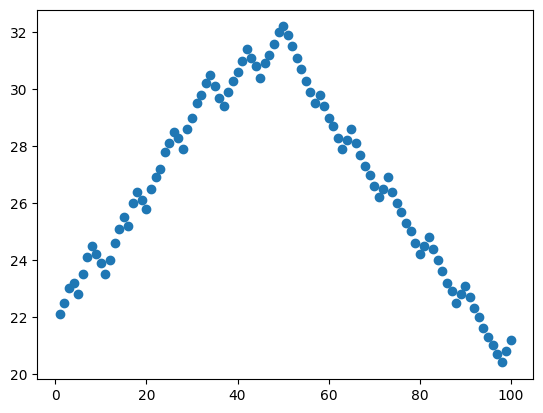

In [21]:
plt.scatter(df["Day"], df["Temperature_C"])


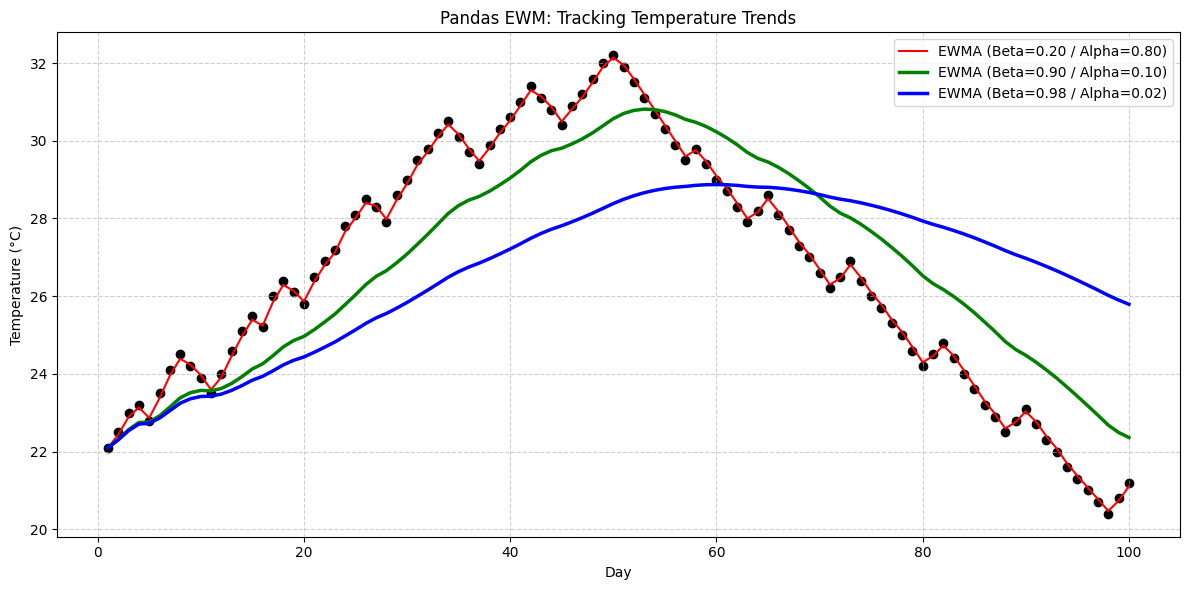

In [26]:
# pandas uses alpha, where alpha = 1 - beta
df['EWMA_beta_0.20'] = df['Temperature_C'].ewm(alpha=0.80).mean() # beta = 0.20
df['EWMA_beta_0.90'] = df['Temperature_C'].ewm(alpha=0.10).mean() # beta = 0.90
df['EWMA_beta_0.98'] = df['Temperature_C'].ewm(alpha=0.02).mean() # beta = 0.98


plt.figure(figsize=(12, 6))

plt.scatter(df['Day'], df['Temperature_C'], color='black')
plt.plot(df['Day'], df['EWMA_beta_0.20'], color='red', linewidth=1.5, label='EWMA (Beta=0.20 / Alpha=0.80)')
plt.plot(df['Day'], df['EWMA_beta_0.90'], color='green', linewidth=2.5, label='EWMA (Beta=0.90 / Alpha=0.10)')
plt.plot(df['Day'], df['EWMA_beta_0.98'], color='blue', linewidth=2.5, label='EWMA (Beta=0.98 / Alpha=0.02)')


plt.title('Pandas EWM: Tracking Temperature Trends')
plt.xlabel('Day')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.show()